# Part 1 - Imports, Loading, Inspect, EDA

1. Import modules
2. Load data using pandas
3. Data cleaning and tidying
   - check datatype
   - check for nan
   - clean data as needed
4. EDA
   - use data viz for EDA
5. Identify Questions Variables

# Import Modules

In [4]:
# Import Modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
    """
    Use a user-defined function for formatting.

    The function should take in two inputs (a tick value ``x`` and a
    position ``pos``), and return a string containing the corresponding
    tick label.
    """
import statsmodels.api as sm


# Load dataframe with pandas

In [5]:
# load dataframe
df = pd.read_csv('all_data.csv')
# confirm loaded correctly
df
# No missing data or null values

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10
...,...,...,...,...
91,Zimbabwe,2011,54.9,1.209845e+10
92,Zimbabwe,2012,56.6,1.424249e+10
93,Zimbabwe,2013,58.0,1.545177e+10
94,Zimbabwe,2014,59.2,1.589105e+10


In [6]:
# --- revise column headers ---
df.columns = (
    df.columns
        .str.strip()
        .str.lower()
        .str.replace('[^0-9a-zA-Z]+', '_', regex=True)
)

# Inspect data and scope

In [7]:
df.dtypes

country                             object
year                                 int64
life_expectancy_at_birth_years_    float64
gdp                                float64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          96 non-null     object 
 1   year                             96 non-null     int64  
 2   life_expectancy_at_birth_years_  96 non-null     float64
 3   gdp                              96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


In [9]:
df.rename(
    columns={'life_expectancy_at_birth_years_': 'le_birth'},
    inplace=True
)

In [10]:
df.country.unique()

array(['Chile', 'China', 'Germany', 'Mexico', 'United States of America',
       'Zimbabwe'], dtype=object)

In [11]:
df.year.unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015])

In [12]:
df.describe()

,year,le_birth,gdp
count,96.000000,96.000000,9.600000e+01
mean,2007.500000,72.789583,3.880499e+12
std,4.633971,10.672882,5.197561e+12
min,2000.000000,44.300000,4.415703e+09
25%,2003.750000,74.475000,1.733018e+11
50%,2007.500000,76.750000,1.280220e+12
75%,2011.250000,78.900000,4.067510e+12
max,2015.000000,81.000000,1.810000e+13


Text(0.5, 1.0, 'Life Expectancy Over Time')

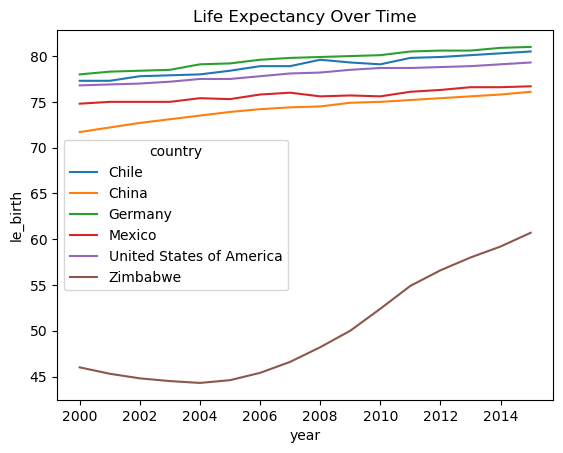

In [23]:
sns.lineplot(data=df, x='year', y='le_birth', hue='country')
plt.title('Life Expectancy Over Time')

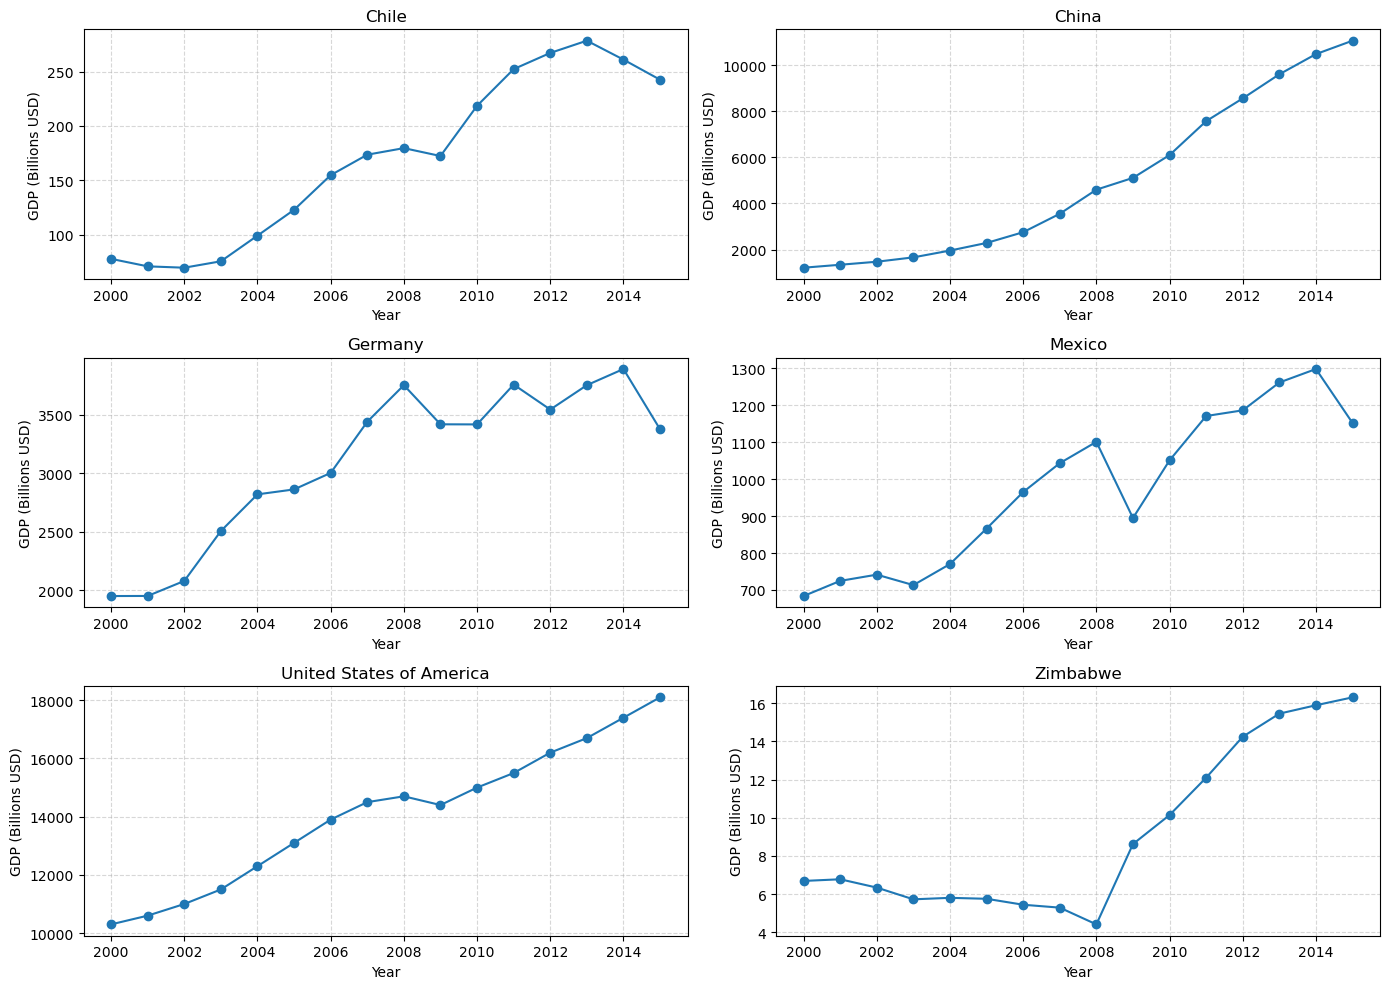

In [56]:
countries = df['country'].unique()

fig, axes = plt.subplots(3, 2, figsize=(14, 10))  # 6 countries → 3 rows × 2 cols
axes = axes.ravel()  # flatten to 1D array so we can loop

for ax, country in zip(axes, countries):
    data = df[df['country'] == country]
    ax.plot(data['year'], data['gdp'] / 1e9, marker='o')  # scale to billions for readability
    ax.set_title(country)
    ax.set_xlabel('Year')
    ax.set_ylabel('GDP (Billions USD)')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [13]:
# --- agg data exploration ---

summary = (
    df.groupby('country')[['le_birth', 'gdp']]
      .agg(['mean', 'min', 'max'])
)
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary.reset_index(inplace=True)

gdp_cols = ['gdp_mean', 'gdp_min', 'gdp_max']
summary[gdp_cols] = (summary[gdp_cols] / 1e9).round(2)
summary['le_range'] = summary.le_birth_max - summary.le_birth_min
summary['gdp_range'] = summary.gdp_max - summary.gdp_min

In [14]:
summary

,country,le_birth_mean,le_birth_min,le_birth_max,gdp_mean,gdp_min,gdp_max,le_range,gdp_range
0,Chile,78.94375,77.3,80.5,169.79,69.74,278.38,3.2,208.64
1,China,74.26250,71.7,76.1,4957.71,1211.35,11064.70,4.4,9853.35
2,Germany,79.65625,78.0,81.0,3094.78,1949.95,3890.61,3.0,1940.66
3,Mexico,75.71875,74.8,76.7,976.65,683.65,1298.46,1.9,614.81
4,United States of America,78.06250,76.8,79.3,14075.00,10300.00,18100.00,2.5,7800.00
5,Zimbabwe,50.09375,44.3,60.7,9.06,4.42,16.30,16.4,11.88


# Part 2 - Questions

Questions

- What is the relationship between GDP and life expectancy at birth per country?
- Does an increase in GDP predict higher life expectancy at birth?
- How does life expectancy at birth in each country change between 2000 and 2016

Statistical Approach

- Linear Regression Model (sm.OLS.from_formula(GDP ~ Life Expectancy at Birth)
    - Correlation - r
    - Variance r^2
    - Beta Coeffecient
- Scatterplot for each country individually
- Scatterplot check for homoscedasticity
- Seaborn Lineplot overlaying with x=year, y=le_brith, hue=country

In [15]:
# X axis scaling problem on each subplot, helper function to calibrate each GDP
def auto_gdp_scale(s):
    """
    Scale a GDP series to Millions / Billions / Trillions.
    Returns: scaled_series, factor, short_unit, long_unit
    """
    gdp_min = s.min()
    gdp_max = s.max()
    gdp_span = gdp_max - gdp_min
    
    if (gdp_max >= 1e12) and (gdp_span > 1e12) :
        return s / 1e12, 1e12, "$1T", "Trillions USD"
        
    elif (gdp_max >= 1e9) and (gdp_span > 1e9):
        return s / 1e9, 1e9, "$1B", "Billions USD"
    
    else:
        return s / 1e6, 1e6, "$1M", "Millions USD"

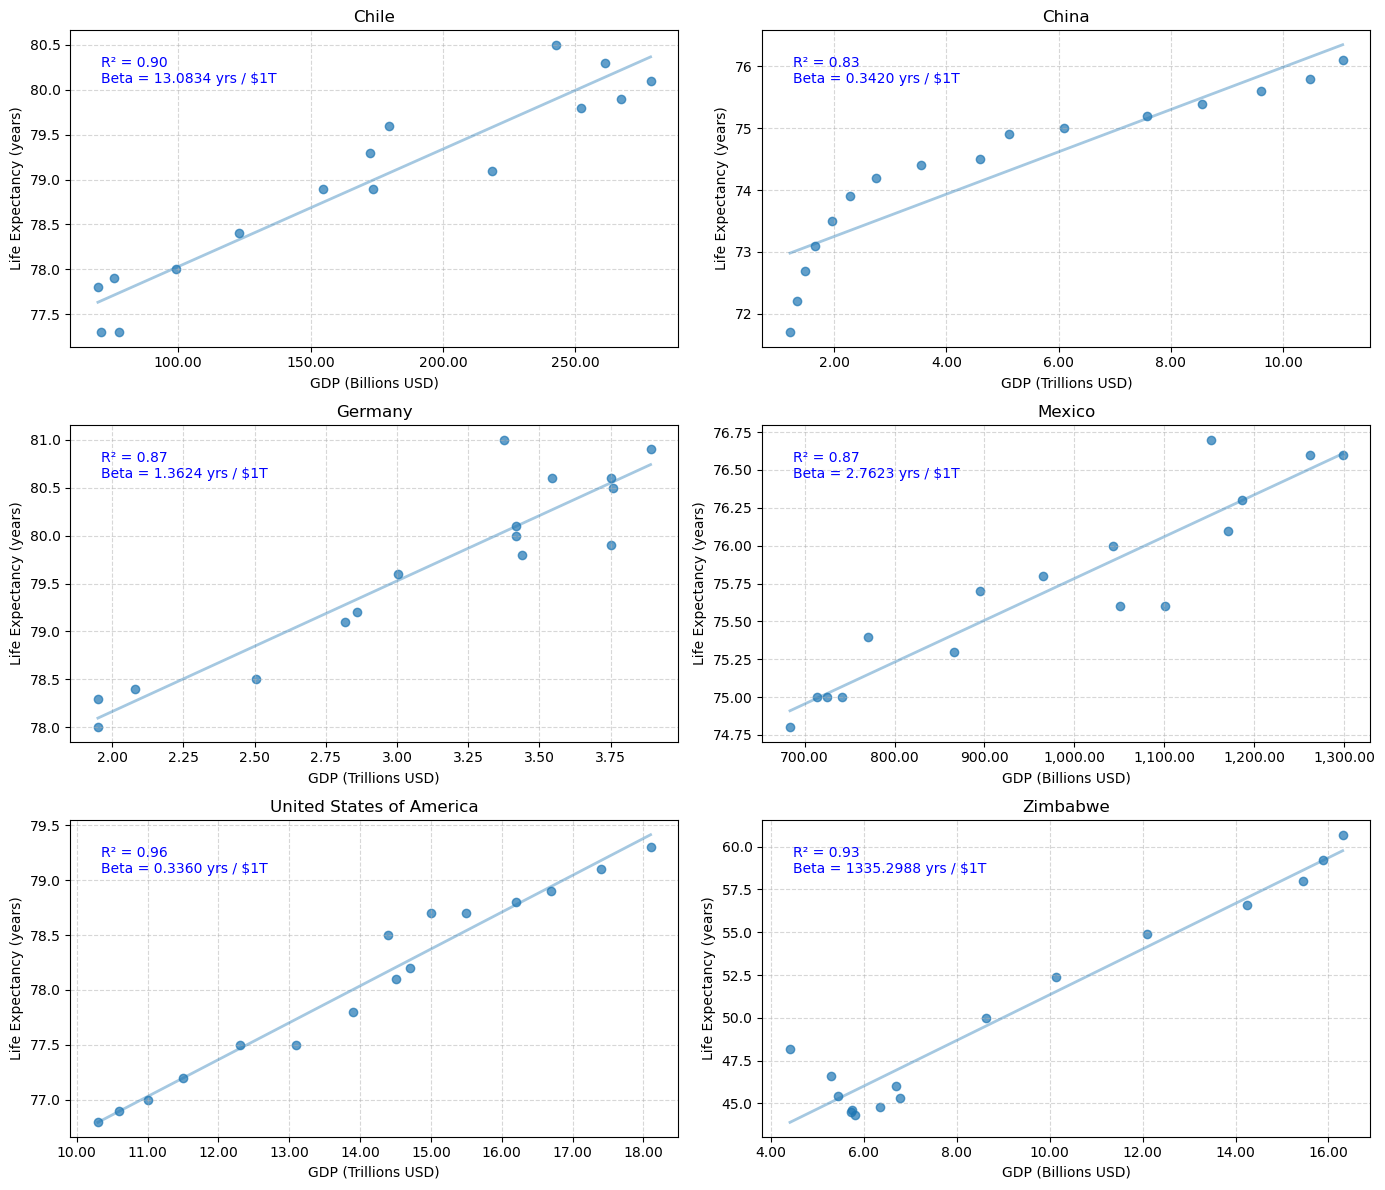

,country,beta_years_per_billion,beta_years_per_trillion,r2
0,Chile,0.013083,13.083372,0.902266
1,China,0.000342,0.342022,0.825419
2,Germany,0.001362,1.362397,0.869927
3,Mexico,0.002762,2.762337,0.869067
4,United States of America,0.000336,0.335981,0.963753
5,Zimbabwe,1.335299,1335.298808,0.933542


In [21]:

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel() # axes 2D frame needs to be flattened to use in for loop 

betas_billion = []  # store comparable slopes

for ax, country in zip(axes, countries):
    data_country = df[df.country == country].copy()

    # (1) For plotting: auto-scale GDP for that country
    data_country["gdp_scaled"], factor, unit_short, unit_long = auto_gdp_scale(data_country["gdp"])

    # (2) For beta comparison: fixed scale in billions
    data_country["gdp_billion"] = data_country["gdp"] / 1e9
    data_country["gdp_trillion"] = data_country["gdp"] / 1e12

    # --- fit models --- 3 seperate versions to test 
    model_scaled  = sm.OLS.from_formula("le_birth ~ gdp_scaled",  data=data_country).fit()
    model_billion = sm.OLS.from_formula("le_birth ~ gdp_billion", data=data_country).fit()
    model_trillion = sm.OLS.from_formula("le_birth ~ gdp_trillion", data=data_country).fit()

    # --- predictions for plot ---
    x_pred = np.linspace(data_country["gdp_scaled"].min(),
                         data_country["gdp_scaled"].max(), 200)
    y_pred = model_scaled.params["Intercept"] + model_scaled.params["gdp_scaled"] * x_pred

    # --- plot ---
    ax.scatter(data_country["gdp_scaled"], data_country["le_birth"], alpha=0.7)
    ax.plot(x_pred, y_pred, lw=2, alpha=.4)
    ax.text(
        0.05, 0.92,
        f"R² = {model_scaled.rsquared:.2f}\nBeta = {model_trillion.params['gdp_trillion']:.4f} yrs / $1T",
        transform=ax.transAxes, fontsize=10, color="blue", va="top"
    )
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.2f}")) #format string for ',' and 2 decimal
    ax.set(xlabel=f"GDP ({unit_long})", ylabel="Life Expectancy (years)", title=country)
    ax.grid(True, linestyle='--', alpha=0.5)

    # --- store comparable slope ---
    betas_billion.append({
        "country": country,
        "beta_years_per_billion": model_billion.params["gdp_billion"],
        "beta_years_per_trillion": model_trillion.params["gdp_trillion"],
        "r2": model_scaled.rsquared,
    })

plt.tight_layout()
plt.show()

# Create a summary DataFrame
beta_df = pd.DataFrame(betas_billion)
beta_df


# Part 3 - Checking for Homoscedasticity

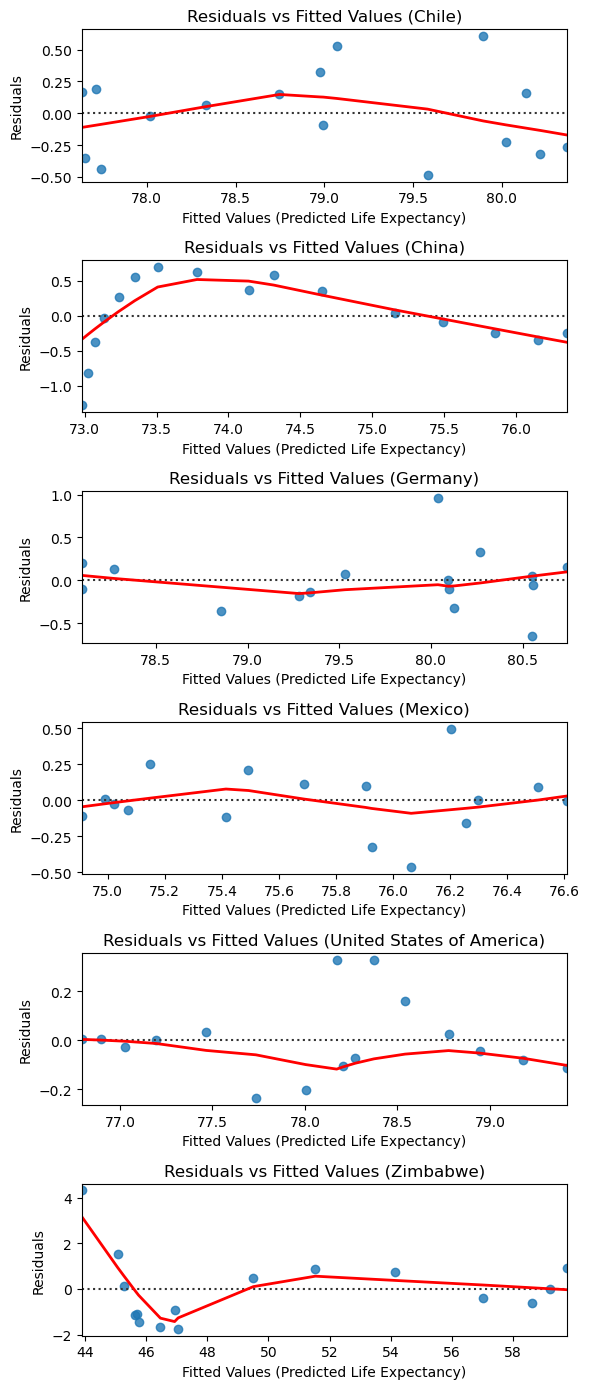

In [17]:
fig, axes = plt.subplots(6,1, figsize=(6, 14))
# axes = axes.ravel()

for ax, country in zip(axes, countries):
    data_country = df[df.country == country].copy()
    data_country["gdp_billion"] = data_country["gdp"] / 1e9
 
    model = sm.OLS.from_formula("le_birth ~ gdp_billion", data=data_country).fit()
    
    fitted = model.fittedvalues
    residuals = model.resid
    
    sns.residplot(x=fitted, y=residuals, lowess=True, 
                  line_kws={'color':'red','lw':2}, ax=ax)
    ax.set(
        title = f"Residuals vs Fitted Values ({country})",
        xlabel = "Fitted Values (Predicted Life Expectancy)",
        ylabel = "Residuals"
    )
plt.tight_layout()
plt.show()

# Part 4 - Observations and Interpretations

## Observations

1. Results from linear regression suggest extremely strong correlation (r > .80 for all 6 countries) between GDP and Life Expectancy at Birth.
2. Using GDP divided by 1e12 to uniformly represent GDP in "Trillions" for an unstandardized regression model, I made comparison of between country's $\beta$ Coefficient to gauge how change in life expectancy would change with growth in  GDP. Results for all countries show a strong, positive relationship between increase in a countries GDP and subsequent increase in life expectancy at birth. Zimbabwe's resulting $\beta$ coeffecient was absurdly large (1335 year increase per trillion dollars) which highlights the obvious problem with this model.
3. The line plot of each country's life expectancy at (as a function of year) shows a clear trend in 5 of 6 countries (Zimbabwe is the exception).  

## Limitations

1. Both 'time' and 'gdp' are naturally increasing variables which suggests this model is overfitted - obviously explaining the extremely high correlation for each country.  It is safe to say that life expectancy and gdp increased together for these countries during this time frame, but dubious to conclude that increase in gdp **causes** an increase in life expectancy.
2. Clear heteroscedasticity in each country's data - largely a function of having only 16 observations per country.
3. Zimbabwe's data clearly highlights a primary model flaw - if Zimbabwe were "gifted" a Trillion dollars, this model would predict an increase in life expectancy of 1335 years!  Additionally - Zimbabwe's GDP was actually declining for the first half of this model.

## Conclusions
Data modeled in this analysis seems to be primarily descriptive and observational.  Predictions based on this model would be unreliable.  While GDP is clearly linked to life expectancy in some way, a reasonable suspicion for further analysis would to examine more granular economic variables for each country (i.e. - healthcare spending) to isolate drivers of life expectancy.